# Participant-level paired changes, and covariate adjustment

Two questions a reviewer will ask of a result resting on 11 and 10 patients.

1. **Who moves?** Group curves can hide influential individuals, so we show each participant's
   prior effect OFF and ON medication, paired, both as observed data and as posterior estimates
   from the reported model.
2. **Does the tremor-dominant result survive covariate adjustment?** Session order, testing site,
   the colour-orientation mapping, disease severity and levodopa-equivalent dose.

**Levodopa-equivalent dose is not available.** The metadata has no dose column. It has free-text
prescriptions (`pd_meds`, present for all 21 patients), from which LEDD could be derived with
standard conversion factors, but that parsing is not implemented and would need clinical checking.
That covariate is therefore not tested here.

Session order, site, mapping and severity are complete for all 21 patients.

Outputs go to the gitignored `outputs/` directory; nothing is written to the data directory.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
import pymc as pm

from config import dir_config
from src.utils import classification_utils
from src.utils.mcmc_cache import CACHE_DIR, FIT_SETTINGS, TERMS, ess_bulk, prepare_trials, rhat, sample_model

processed_dir = Path(dir_config.data.processed)
filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)
subjects_map, _ = classification_utils.get_subject_classification_ids(processed_metadata)

OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve()
assert not str(OUTPUT_DIR).startswith(str(processed_dir.parents[0]))
OUTPUT_DIR.mkdir(exist_ok=True)

SUBTYPES = {"tremor": "tremor_dominant", "bradykinetic": "bradykinesia_dominant"}
TITLES = {"tremor": "Tremor Dominant", "bradykinetic": "Bradykinesia Dominant"}
COL_MED, COL = TERMS.index("col:med"), TERMS.index("col")
POSTERIOR_COLOR = "#B5541D"


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Part 1a. Observed paired changes

Model-free: each session's prior effect is the proportion of positive choices on Positive-Prior
trials minus Equal-Prior trials, at 0% coherence, exactly the quantity in the Figure 1 and 2 insets.


In [3]:
zero_coh = filtered_data[filtered_data["coherence"] == 0]
observed = (zero_coh.groupby(["subject_id", "medication", "color"])["choice"].mean()
            .unstack("color"))
observed = (observed[1] - observed[0]).unstack("medication").rename(columns={"off": "OFF", "on": "ON"})
observed["change"] = observed["ON"] - observed["OFF"]
observed["subtype"] = np.where(observed.index.isin(subjects_map["tremor_dominant"]), "tremor",
                       np.where(observed.index.isin(subjects_map["bradykinesia_dominant"]), "bradykinetic", None))
observed = observed[observed["subtype"].notna()].sort_values(["subtype", "change"])
observed.round(3)


medication,OFF,ON,change,subtype
subject_id,,,,
P22,0.162,-0.188,-0.350,bradykinetic
P23,0.443,0.102,-0.341,bradykinetic
P4,0.059,-0.094,-0.152,bradykinetic
P13,0.026,-0.056,-0.082,bradykinetic
P33,0.132,0.070,-0.062,bradykinetic
P9,-0.087,-0.043,0.045,bradykinetic
P34,-0.051,0.050,0.101,bradykinetic
P28,0.034,0.177,0.143,bradykinetic
P20,-0.012,0.132,0.144,bradykinetic


In [4]:
summary = observed.groupby("subtype").agg(n=("change", "size"), improved=("change", lambda x: int((x > 0).sum())),
                                          mean_change=("change", "mean"), min_change=("change", "min"),
                                          max_change=("change", "max"))
summary.round(3)


,n,improved,mean_change,min_change,max_change
subtype,,,,,
bradykinetic,10,5,-0.021,-0.35,0.343
tremor,11,7,0.112,-0.33,0.366


## Part 1b. Model-based paired estimates


In [5]:
idata, subject_ids, subsets = {}, {}, {}
for subtype, key in SUBTYPES.items():
    subsets[subtype] = prepare_trials(filtered_data, subjects_map[key])
    subject_ids[subtype] = subsets[subtype]["subject_id"].unique()
    idata[subtype] = sample_model(subsets[subtype], **FIT_SETTINGS)
    with np.load(CACHE_DIR / f"{subtype}.npz") as cached:   # read only
        assert np.allclose(cached["beta"], idata[subtype].posterior["beta"].values, rtol=0, atol=1e-10)
    print(f"{subtype}: reproduces the reported posterior; "
          f"{int(idata[subtype].sample_stats['diverging'].values.sum())} divergences")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 110 seconds.
Initializing NUTS using jitter+adapt_diag...


tremor: reproduces the reported posterior; 0 divergences


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 70 seconds.


bradykinetic: reproduces the reported posterior; 0 divergences


In [6]:
# participant prior effect in each medication state:
#   (col + u_col) +/- 0.5 * (col:med + u_col:med)
paired_rows, paired_draws = [], {}
for subtype in SUBTYPES:
    post = idata[subtype].posterior
    beta, sd_u, z_u = post["beta"].values, post["sd_u"].values, post["z_u"].values
    u = z_u * sd_u[:, :, None, :]                                   # (chain, draw, participant, term)
    col_i = (beta[..., COL][..., None] + u[..., COL]).reshape(-1, len(subject_ids[subtype]))
    cm_i = (beta[..., COL_MED][..., None] + u[..., COL_MED]).reshape(-1, len(subject_ids[subtype]))
    paired_draws[subtype] = {"OFF": col_i - 0.5 * cm_i, "ON": col_i + 0.5 * cm_i, "change": cm_i}
    for j, participant in enumerate(subject_ids[subtype]):
        row = {"participant_id": participant, "subtype": subtype}
        for state in ("OFF", "ON", "change"):
            draws = paired_draws[subtype][state][:, j]
            low, high = np.percentile(draws, [2.5, 97.5])
            row[state] = draws.mean(); row[f"{state}_lo"] = low; row[f"{state}_hi"] = high
        row["P(change > 0)"] = (paired_draws[subtype]["change"][:, j] > 0).mean()
        paired_rows.append(row)

paired = pd.DataFrame(paired_rows).set_index("participant_id")
paired[["subtype", "OFF", "ON", "change", "change_lo", "change_hi", "P(change > 0)"]].round(3)


,subtype,OFF,ON,change,change_lo,change_hi,P(change > 0)
participant_id,,,,,,,
P11,tremor,-0.018,0.367,0.385,-0.184,0.938,0.907
P19,tremor,-0.183,0.112,0.295,-0.194,0.787,0.880
P29,tremor,-0.426,0.734,1.160,0.628,1.697,1.000
P6,tremor,-0.855,0.877,1.732,1.121,2.373,1.000
P32,tremor,0.311,0.699,0.388,-0.116,0.899,0.926
P31,tremor,1.005,0.101,-0.904,-1.444,-0.360,0.000
P12,tremor,-0.097,0.768,0.864,0.242,1.468,0.997
P18,tremor,0.781,0.822,0.041,-0.484,0.572,0.572
P3,tremor,-0.213,0.252,0.465,-0.022,0.941,0.969


### Figure. Paired OFF to ON prior effect


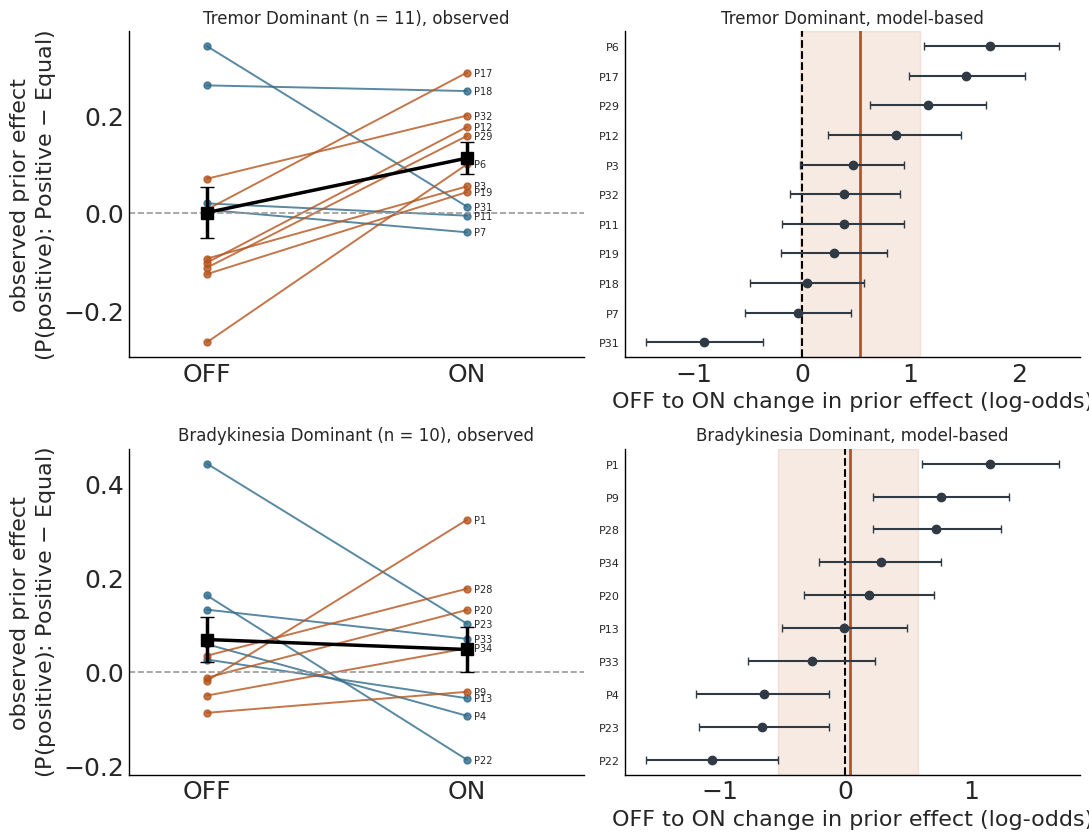

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for row, subtype in enumerate(SUBTYPES):
    obs = observed[observed["subtype"] == subtype]
    ax = axes[row, 0]
    for participant, r in obs.iterrows():
        color = POSTERIOR_COLOR if r["change"] > 0 else "#2F6B8A"
        ax.plot([0, 1], [r["OFF"], r["ON"]], "-o", color=color, ms=5, lw=1.4, alpha=0.8)
        ax.annotate(participant, (1, r["ON"]), xytext=(5, 0), textcoords="offset points", fontsize=7, va="center")
    ax.errorbar([0, 1], [obs["OFF"].mean(), obs["ON"].mean()], yerr=[stats.sem(obs["OFF"]), stats.sem(obs["ON"])],
                color="k", marker="s", ms=9, lw=2.5, capsize=5, zorder=5)
    ax.axhline(0, color="0.6", ls="--", lw=1.2)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"]); ax.set_xlim(-0.3, 1.45)
    ax.set_ylabel("observed prior effect\n(P(positive): Positive $-$ Equal)")
    ax.set_title(f"{TITLES[subtype]} (n = {len(obs)}), observed", fontsize=12)

    block = paired[paired["subtype"] == subtype].sort_values("change")
    ax = axes[row, 1]
    positions = np.arange(len(block))
    ax.errorbar(block["change"], positions,
                xerr=[block["change"] - block["change_lo"], block["change_hi"] - block["change"]],
                ls="", marker="o", ms=6, color="#2F3A45", capsize=3, lw=1.5)
    pop = idata[subtype].posterior["beta"].values[..., COL_MED].ravel()
    ax.axvspan(*np.percentile(pop, [2.5, 97.5]), color=POSTERIOR_COLOR, alpha=0.12, zorder=0)
    ax.axvline(pop.mean(), color=POSTERIOR_COLOR, lw=2, zorder=1)
    ax.axvline(0, color="k", ls="--", lw=1.5, zorder=1)
    ax.set_yticks(positions); ax.set_yticklabels(block.index, fontsize=8)
    ax.set_xlabel("OFF to ON change in prior effect (log-odds)")
    ax.set_title(f"{TITLES[subtype]}, model-based", fontsize=12)

for ax in axes.ravel():
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paired_participant_changes.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "paired_participant_changes.png", dpi=200, bbox_inches="tight")
plt.show()


## Part 2. Covariate adjustment

The medication contrast is within-participant, so a covariate that is constant within a participant
(order, site, severity) cannot confound it directly. It can only change the effect if it *modulates*
it, so each is entered with its interaction on colour, medication and colour x medication.

The colour-orientation mapping is different: it varies **within** participant, since all 21 patients
had a different mapping in their second session. It can therefore contribute directly to an OFF-to-ON
difference. Which colour carried the prior (red vs green) and which orientation it favoured (left vs
right) are entered as trial-level covariates with their colour interactions.

Every model keeps the reported random-effects structure. Between-participant covariates get no
random slope. Each fit uses the reported sampler settings.


In [8]:
session_info = (processed_metadata.dropna(subset=["treatment"])
                .assign(medication=lambda x: x["treatment"].str.lower())
                .set_index(["subject_id", "medication"]))


def covariate_columns(subset, subtype):
    """Session- and participant-level covariates aligned to the trial table, all centred."""
    key = list(zip(subset["subject_id"], subset["medication"]))
    info = session_info.loc[key]
    subject_first = processed_metadata.drop_duplicates("subject_id").set_index("subject_id")
    subj = subject_first.loc[subset["subject_id"]]
    out = {}
    # between-participant
    out["order"] = (subj["off_med_first"].to_numpy() - 0.5)                      # OFF first = +0.5
    out["site"] = np.where(subj["experiment_site"].to_numpy() == "Harvard", 0.5, -0.5)
    severity = subj["UPDRS"].to_numpy(dtype=float)
    out["severity"] = (severity - np.nanmean(severity)) / np.nanstd(severity)
    # within-participant (session level): which colour carried the prior, which direction it favoured
    condition = info["prior_condition"].to_numpy()
    out["red"] = np.where(np.char.startswith(condition.astype(str), "r"), 0.5, -0.5)
    out["left"] = np.where(np.char.endswith(condition.astype(str), "l"), 0.5, -0.5)
    return {k: np.nan_to_num(v, nan=0.0) for k, v in out.items()}


def build(subset, covariates, extra):
    """Base design (7 columns, random effects) plus fixed covariate interactions."""
    base = np.column_stack([np.ones(len(subset)), subset["coh"], subset["col"], subset["med"],
                            subset["col"] * subset["med"], subset["prev_rc"],
                            subset["prev_rc"] * subset["med"]])
    names, cols = list(TERMS), [base]
    for name in extra:
        c = covariates[name]
        if name in ("red", "left"):          # within-participant: main effect + colour interaction
            block, block_names = [c, c * subset["col"]], [name, f"{name}:col"]
        else:                                  # between-participant: allow it to modulate the effect
            block = [c, c * subset["col"], c * subset["med"], c * subset["col"] * subset["med"]]
            block_names = [name, f"{name}:col", f"{name}:med", f"{name}:col:med"]
        cols.append(np.column_stack(block)); names += block_names
    return np.column_stack(cols).astype("float64"), names


def fit_adjusted(subset, design, seed=0):
    participants = subset["subject_id"].unique()
    index = subset["subject_id"].map({s: i for i, s in enumerate(participants)}).to_numpy()
    n_re = len(TERMS)
    y = subset["choice"].to_numpy().astype("int8")
    with pm.Model():
        population = pm.Normal("beta", 0, 2.5, shape=design.shape[1])
        subject_sd = pm.HalfNormal("sd_u", 1.0, shape=n_re)
        subject_z = pm.Normal("z_u", 0, 1, shape=(len(participants), n_re))
        eta = pm.math.sum(design * population, axis=1) + pm.math.sum(
            design[:, :n_re] * (subject_z * subject_sd)[index], axis=1)
        pm.Bernoulli("obs", logit_p=eta, observed=y)
        return pm.sample(FIT_SETTINGS["draws"], tune=FIT_SETTINGS["tune"], chains=FIT_SETTINGS["chains"],
                         cores=FIT_SETTINGS["chains"], target_accept=FIT_SETTINGS["target_accept"],
                         random_seed=seed, progressbar=False)


MODELS = {"reported model": [], "+ session order": ["order"], "+ site": ["site"],
          "+ disease severity (UPDRS)": ["severity"], "+ colour-orientation mapping": ["red", "left"],
          "+ all of the above": ["order", "site", "severity", "red", "left"]}

adjusted_rows = []
for subtype in SUBTYPES:
    subset = subsets[subtype]
    covariates = covariate_columns(subset, subtype)
    for label, extra in MODELS.items():
        design, names = build(subset, covariates, extra)
        fitted = fit_adjusted(subset, design)
        beta = fitted.posterior["beta"].values
        draws = beta[..., names.index("col:med")].ravel()
        low, high = np.percentile(draws, [2.5, 97.5])
        adjusted_rows.append({"subtype": subtype, "model": label, "n covariate terms": len(names) - len(TERMS),
                              "col:med": draws.mean(), "2.5%": low, "97.5%": high,
                              "P(> 0)": (draws > 0).mean(),
                              "divergences": int(fitted.sample_stats["diverging"].values.sum()),
                              "max r_hat": max(rhat(beta[..., k]) for k in range(beta.shape[-1]))})
        print(f"{subtype:13s} {label:30s} col:med = {draws.mean():+.3f} [{low:+.3f}, {high:+.3f}] "
              f"P(>0) = {(draws > 0).mean():.3f}")

adjusted = pd.DataFrame(adjusted_rows).set_index(["subtype", "model"])
adjusted.round(3)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 114 seconds.
Initializing NUTS using jitter+adapt_diag...


tremor        reported model                 col:med = +0.544 [-0.009, +1.082] P(>0) = 0.974


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 151 seconds.
Initializing NUTS using jitter+adapt_diag...


tremor        + session order                col:med = +0.520 [-0.073, +1.122] P(>0) = 0.959


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 147 seconds.
Initializing NUTS using jitter+adapt_diag...


...

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 168 seconds.
Initializing NUTS using jitter+adapt_diag...


bradykinetic  + colour-orientation mapping   col:med = +0.055 [-0.450, +0.589] P(>0) = 0.584


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 254 seconds.


bradykinetic  + all of the above             col:med = +0.264 [-0.326, +0.788] P(>0) = 0.846


n covariate terms  col:med   2.5%  \
subtype      model                                                             
tremor       reported model                                0    0.544 -0.009   
             + session order                               4    0.520 -0.073   
             + site                                        4    0.419 -0.231   
             + disease severity (UPDRS)                    4    0.544  0.089   
             + colour-orientation mapping                  4    0.450 -0.032   
             + all of the above                           16    0.265 -0.130   
bradykinetic reported model                                0    0.053 -0.512   
             + session order                               4    0.045 -0.573   
             + site                                        4    0.105 -0.508   
             + disease severity (UPDRS)                    4    0.045 -0.535   
             + colour-orientation mapping                  4    0.055 -0.450   
             + all of the above                           16    0.264 -0.326   

                                           97.5%  P(> 0)  divergences  \
subtype      model                                                      
tremor       reported model                1.082   0.974            0   
             + session order               1.122   0.959            0   
             + site                        1.049   0.908            0   
             + disease severity (UPDRS)    1.001   0.986            0   
             + colour-orientation mapping  0.954   0.966            0   
             + all of the above            0.669   0.926            0   
bradykinetic reported model                0.606   0.577            0   
             + session order               0.644   0.562            0   
             + site                        0.743   0.642            0   
             + disease severity (UPDRS)    0.619   0.575            0   
             + colour-orientation mapping  0.589   0.584            0   
             + all of the above            0.788   0.846            0   

                                           max r_hat  
subtype      model                                    
tremor       reported model                    1.005  
             + session order                   1.003  
             + site                            1.005  
             + disease severity (UPDRS)        1.003  
             + colour-orientation mapping      1.006  
             + all of the above                1.003  
bradykinetic reported model                    1.004  
             + session order                   1.005  
             + site                            1.003  
             + disease severity (UPDRS)        1.004  
             + colour-orientation mapping      1.003  
             + all of the above                1.004

### Figure. Sensitivity of the medication effect to covariate adjustment


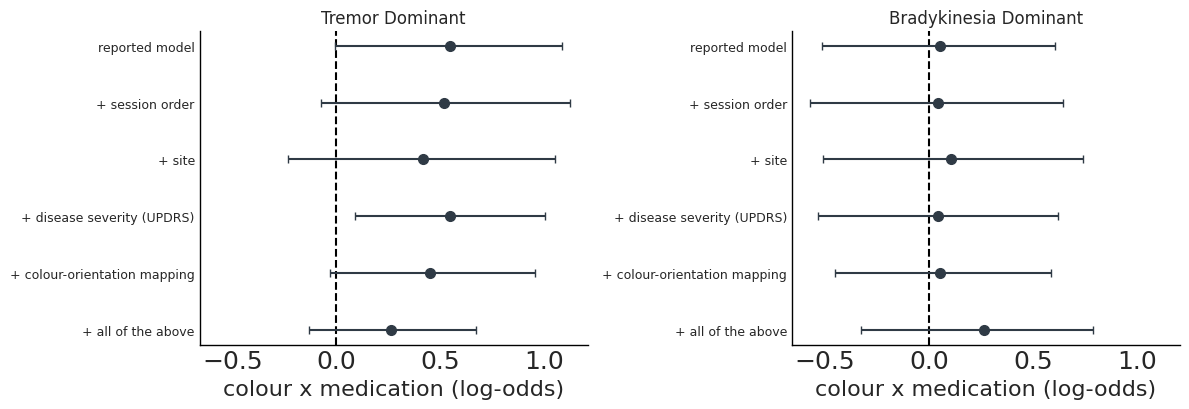

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, subtype in zip(axes, SUBTYPES):
    block = adjusted.loc[subtype].iloc[::-1]
    positions = np.arange(len(block))
    ax.axvline(0, color="k", ls="--", lw=1.5)
    ax.errorbar(block["col:med"], positions,
                xerr=[block["col:med"] - block["2.5%"], block["97.5%"] - block["col:med"]],
                ls="", marker="o", ms=7, color="#2F3A45", capsize=3, lw=1.5)
    ax.set_yticks(positions); ax.set_yticklabels(block.index, fontsize=9)
    ax.set_xlabel("colour x medication (log-odds)")
    ax.set_title(TITLES[subtype], fontsize=12)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "covariate_adjustment.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "covariate_adjustment.png", dpi=200, bbox_inches="tight")
plt.show()


In [10]:
paired.to_csv(OUTPUT_DIR / "paired_participant_changes.csv")
observed.to_csv(OUTPUT_DIR / "observed_paired_changes.csv")
adjusted.to_csv(OUTPUT_DIR / "covariate_adjustment.csv")
print("saved:", *(f.name for f in sorted(OUTPUT_DIR.glob('*'))), sep="\n  ")


saved:
  covariate_adjustment.csv
  covariate_adjustment.pdf
  covariate_adjustment.png
  figure5a_participant_effects.pdf
  figure5a_participant_effects.png
  observed_paired_changes.csv
  paired_participant_changes.csv
  paired_participant_changes.pdf
  paired_participant_changes.png
  participant_medication_effects.csv
  participant_medication_effects_draws.npz
  robustness_cache
  subtype_comparison.csv
  subtype_comparison.pdf
  subtype_comparison.png
  subtype_comparison_draws.npz
